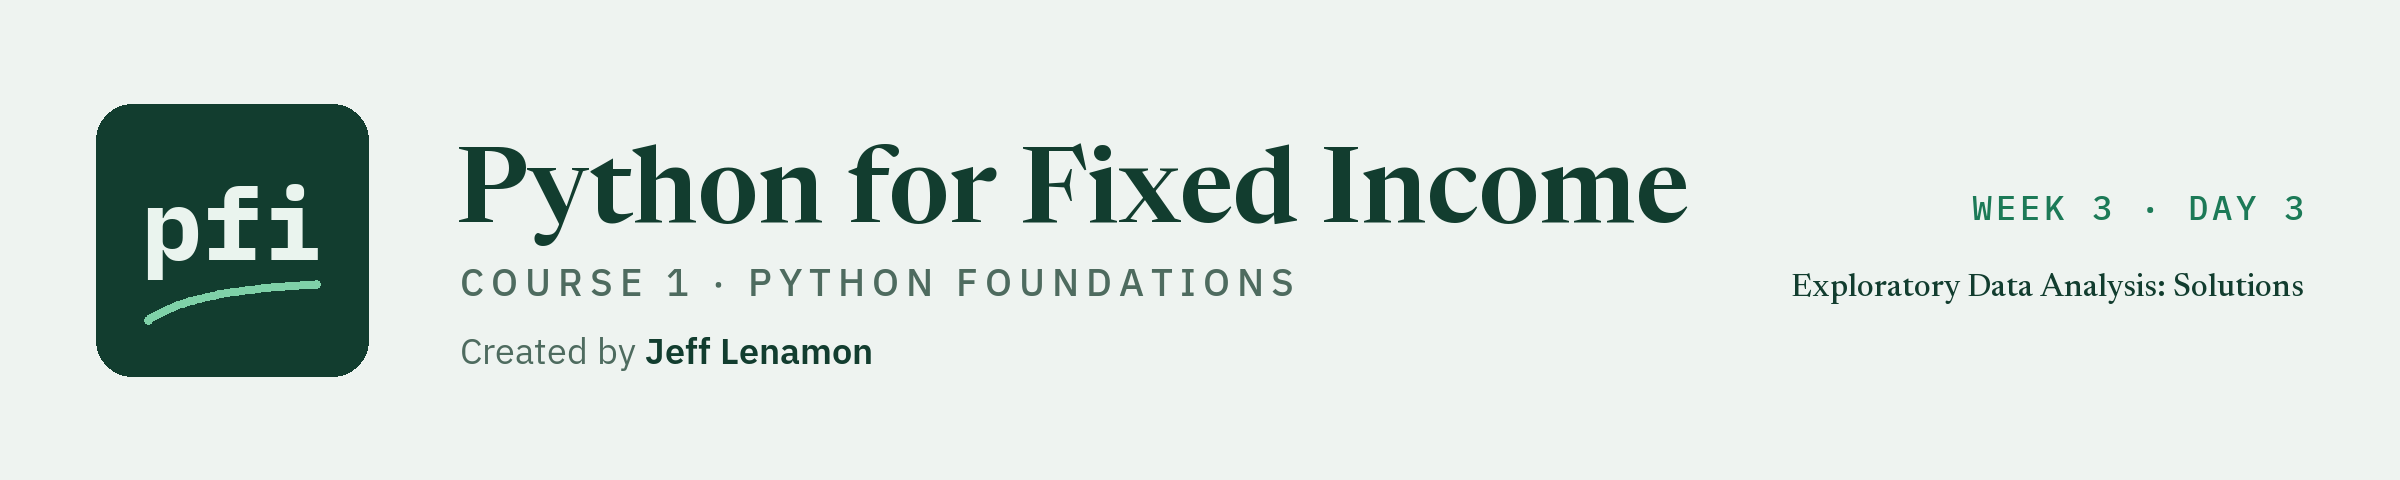

# Exploratory Data Analysis - Solutions

Week 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day3/13_exploratory_data_analysis_solutions.ipynb)

## Exercises

The exercises use the same extract and ask about columns and cuts the lesson did not examine: the price, the sectors, the DTS, and the coupon. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell. Exercise 5 asks for a function that builds on `clean_holdings`. Print the numbers you rely on, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, loads a fresh `raw`, defines `clean_holdings` as in section 13.8, and builds `book` again by calling it. It prints the shape of `raw`, (204, 19), the shape of `book`, (200, 22), and the market value of the book, 490819215.0.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    # ... is the placeholder, and None is what a function returns before its body is written
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two files. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

raw = pd.read_csv(data_folder + 'holdings_messy.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the function of section 13.8: the lesson's decisions in one place
def clean_holdings(raw, ratings):
    """Apply the day's decisions to the extract as received and return the cleaned table.

    raw is the holdings extract and ratings is the rating scale. Neither is changed.
    """
    # work on a copy, so the table as received stays as it arrived
    book = raw.copy()

    # the three date columns become dates, and a date that cannot be read stops the function
    for column in ['as_of_date', 'maturity', 'price_date']:
        book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
        assert book[column].notna().all(), f'{column} holds a date that could not be read'

    # decision 1: remove the rows sent twice, keeping the first appearance of each
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: the stale prices are reported and not changed, so there is no line for them

    # decision 4: join the rating scale, then label the bonds with no rating
    book = pd.merge(book, ratings, on='rating', how='left', validate='many_to_one')
    book['bucket'] = book['bucket'].fillna('Not rated')
    book['grade'] = book['grade'].fillna('Not rated')

    # decision 5: a yield below the lower limit of the IQR rule was entered as a decimal, so it is multiplied by 100
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    entered_as_decimal = book['yield_pct'] < q1 - 1.5 * (q3 - q1)
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real, and they stay

    return book


book = clean_holdings(raw, ratings)

print(raw.shape)
print(book.shape)
print(book['market_value'].sum())

(204, 19)
(200, 22)
490819215.0


### Exercise 1

Q. Apply the IQR rule to the `price` column of `book`. What are the lower and upper limits, and how many bonds are below the lower limit and above the upper limit? Store the two counts in **ex1_below** and **ex1_above**. Then look at the rating and the OAS of the flagged bonds, and say whether they look like errors or real extremes.

First quartile: 95.14  third quartile: 103.004  IQR: 7.864
Lower limit: 83.344  upper limit: 114.8
Below: 4  above: 4
    ticker rating  coupon    price  yield_pct   oas  duration
17    CLDB      B   9.500   62.045     18.734  1446     4.513
117   NEVX   BBB-   3.875   73.873      6.080   153    12.898
150   SYLX    NaN   3.625   76.903      5.173    59    16.042
108   MULN     BB   3.875   81.455      6.265   189     8.324
76    GRON      A   7.250  116.795      5.116    76     7.303
146   SKEY    BBB   7.875  117.164      6.506   193    12.065
90    KEZA     A-   7.750  118.201      5.707   128     8.216
123   PLEA     AA   7.250  119.131      4.706    38     6.994


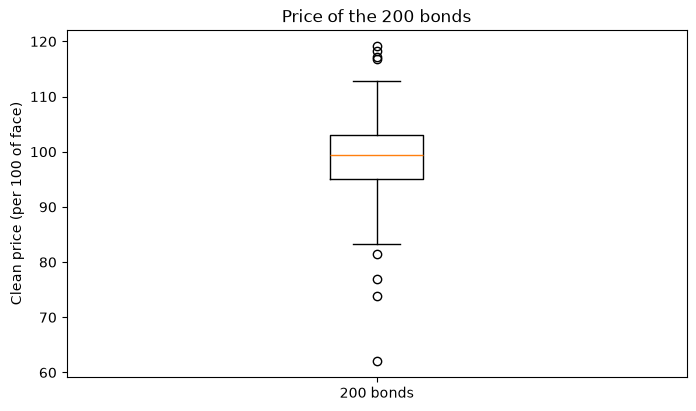

In [2]:
# the quartiles, the IQR, and the two limits
q1 = book['price'].quantile(0.25)
q3 = book['price'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print('First quartile:', q1, ' third quartile:', q3, ' IQR:', round(iqr, 3))
print('Lower limit:', round(lower_limit, 3), ' upper limit:', round(upper_limit, 3))

ex1_below = (book['price'] < lower_limit).sum()
ex1_above = (book['price'] > upper_limit).sum()
print('Below:', ex1_below, ' above:', ex1_above)

# the flagged bonds, with the columns that can confirm or contradict the price
flagged = book[(book['price'] < lower_limit) | (book['price'] > upper_limit)]
print(flagged[['ticker', 'rating', 'coupon', 'price', 'yield_pct', 'oas', 'duration']].sort_values('price'))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(book['price'], tick_labels=['200 bonds'])
ax.set_title('Price of the 200 bonds')
ax.set_ylabel('Clean price (per 100 of face)')
plt.show()

* The quartiles are 95.14 and 103.004, so the IQR is 7.864 and the limits are 83.344 and 114.8. 4 bonds are below the lower limit and 4 are above the upper limit.
* The lowest is the B bond at 62.045, with an OAS of 1,446 basis points and a yield of 18.734 percent: one of the 14 wide bonds of the lesson. Its low price, wide spread, and high yield agree with each other.
* The other three low prices are a different kind of bond. Their coupons are 3.875 percent or less, their durations run from 8.324 to 16.042 years, and their OAS values are 59 to 189 basis points. A low coupon on a long bond gives a price well below 100 with no wide spread at all.
* The four high prices are bonds with coupons of 7.25 to 7.875 percent and yields of 4.706 to 6.506 percent. A coupon well above the yield gives a price well above 100.
* None of the eight looks like an error. Every one is explained by its other columns. They are real extremes and they stay.

In [3]:
check('Exercise 1 below the lower limit', ex1_below, 4)
check('Exercise 1 above the upper limit', ex1_above, 4)

Exercise 1 below the lower limit: correct
Exercise 1 above the upper limit: correct


### Exercise 2

Q. Suppose the five bonds with no rating were dropped with `dropna(subset=['rating'])`. Work out the market value of each sector before and after. Which sector loses the most market value, and how many dollars does it lose? Store the answers in **ex2_sector** and **ex2_lost**.

In [4]:
# market value by sector with every bond, and with the unrated bonds dropped
all_bonds = book.groupby('sector')['market_value'].sum()
rated_only = book.dropna(subset=['rating']).groupby('sector')['market_value'].sum()

# the loss in each sector, largest first
lost = (all_bonds - rated_only).sort_values(ascending=False)
print(lost)

ex2_sector = lost.idxmax()
ex2_lost = lost.max()

print('Largest loss:', ex2_sector, ex2_lost, 'dollars')
print('Share of that sector:', round(ex2_lost / all_bonds.loc[ex2_sector] * 100, 2), 'percent')
print('Total lost:', lost.sum())

sector
Materials         9532157.5
Transportation    3472875.0
Telecom           1529605.0
Industrials        807900.0
Energy                  0.0
Consumer                0.0
Financials              0.0
Health Care             0.0
Technology              0.0
Utilities               0.0
Name: market_value, dtype: float64
Largest loss: Materials 9532157.5 dollars
Share of that sector: 13.29 percent
Total lost: 15342537.5


* Materials loses the most: 9,532,157.5 dollars, which is 13.29 percent of the sector's market value. Two of the five unrated bonds are in Materials.
* Transportation, Telecom, and Industrials lose one bond each, and the other six sectors lose nothing. The total is the 15,342,537.5 dollars of the lesson.
* Dropping rows does not shrink every group evenly. Here it would make Materials look 13 percent smaller than it is, and a sector report would show that with no sign of why.

In [5]:
check('Exercise 2 sector', ex2_sector, 'Materials')
check('Exercise 2 dollars lost', ex2_lost, 9532157.5)

Exercise 2 sector: correct
Exercise 2 dollars lost: correct


### Exercise 3

Q. Describe the `dts` column of `book` on its own. Work out its mean and its median, each rounded to 2 decimal places, and store them in **ex3_mean** and **ex3_median**. Then work out a z-score for each bond's DTS and count the bonds with a z-score above 3. Store the count in **ex3_count**. Draw the histogram with the mean and the median marked.

Mean: 1133.22  median: 811.0  skew: 1.95
Standard deviation: 1065.7
Bonds with a z-score above 3: 6
    ticker rating  duration   oas     dts
17    CLDB      B     4.513  1446  6525.8
18    CLDB      B     9.019   520  4689.9
66    FESR   CCC+     7.252   614  4452.7
72    GALX     B-     6.506   679  4417.6
111   NEVN     B-     6.120   719  4400.3
132   PRAN   CCC+     5.058   871  4405.5
   ticker rating  duration   oas     dts
65   FESR   CCC+     1.546  1551  2397.8


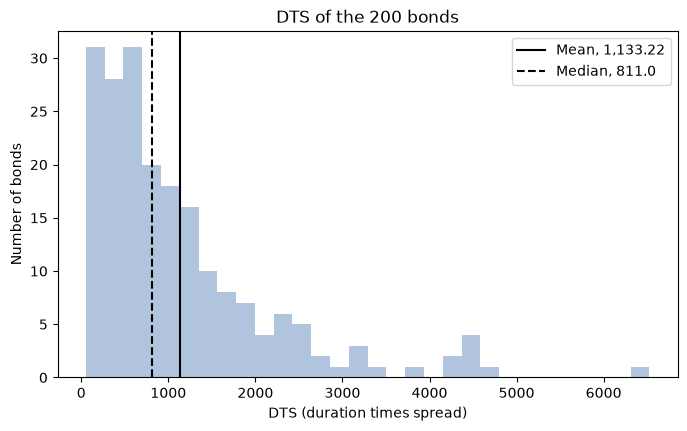

In [6]:
ex3_mean = round(book['dts'].mean(), 2)
ex3_median = round(book['dts'].median(), 2)

print('Mean:', ex3_mean, ' median:', ex3_median, ' skew:', round(book['dts'].skew(), 2))

# one z-score for each bond: the distance from the mean in standard deviations
z = (book['dts'] - book['dts'].mean()) / book['dts'].std()
ex3_count = (z > 3).sum()

print('Standard deviation:', round(book['dts'].std(), 2))
print('Bonds with a z-score above 3:', ex3_count)
print(book.loc[z > 3, ['ticker', 'rating', 'duration', 'oas', 'dts']])

# the bond with the widest OAS in the book, for comparison
print(book.loc[[book['oas'].idxmax()], ['ticker', 'rating', 'duration', 'oas', 'dts']])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(book['dts'], bins=30, color='lightsteelblue')
ax.axvline(book['dts'].mean(), color='black', label='Mean, 1,133.22')
ax.axvline(book['dts'].median(), color='black', linestyle='--', label='Median, 811.0')
ax.legend()
ax.set_title('DTS of the 200 bonds')
ax.set_xlabel('DTS (duration times spread)')
ax.set_ylabel('Number of bonds')
plt.show()

* The mean DTS is 1,133.22 and the median is 811.0, with a skew of 1.95. The tail is on the right and the mean is to the right of the median, the usual pattern.
* 6 bonds have a z-score above 3, with DTS values from 4,400.3 to 6,525.8. All six are rated B or lower.
* They are not the same bonds as the three OAS outliers of section 13.5. Two of those three are here, with OAS values of 1,446 and 871. The third, the widest bond in the book at 1,551 basis points, is not: its duration is 1.546 years, so its DTS is 2,397.8. DTS is duration times spread, and a bond gets a large one only when both are sizeable.
* An outlier in one column is not always an outlier in another. All six are real: each DTS is its own duration times its own OAS.

In [7]:
check('Exercise 3 mean', ex3_mean, 1133.22)
check('Exercise 3 median', ex3_median, 811.0)
check('Exercise 3 count', ex3_count, 6)

Exercise 3 mean: correct
Exercise 3 median: correct
Exercise 3 count: correct


### Exercise 4

Q. What is the correlation of `coupon` and `price` across all 200 bonds, across the Investment Grade bonds, and across the High Yield bonds? Round each to 2 decimal places and store them in **ex4_all**, **ex4_ig**, and **ex4_hy**. Draw the two grades as two scatter plots side by side.

All 200 bonds: 0.31
Investment Grade, 125 bonds: 0.81
High Yield, 70 bonds: 0.07
   ticker  coupon   price
17   CLDB     9.5  62.045


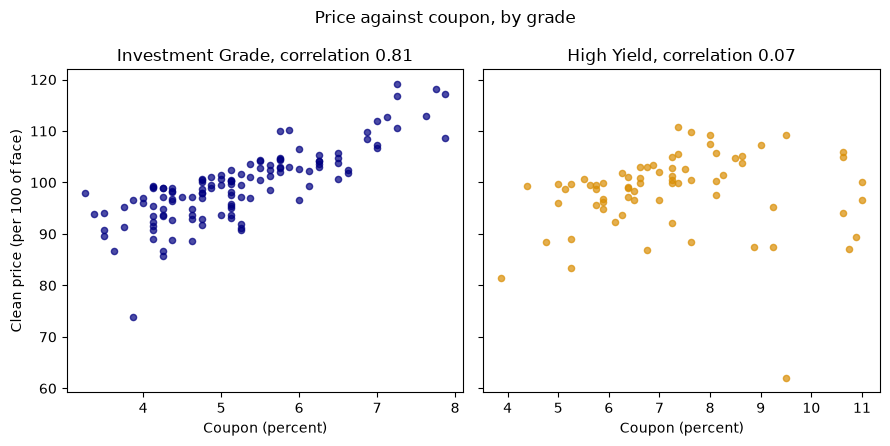

In [8]:
ig = book[book['grade'] == 'Investment Grade']
hy = book[book['grade'] == 'High Yield']

ex4_all = round(book['coupon'].corr(book['price']), 2)
ex4_ig = round(ig['coupon'].corr(ig['price']), 2)
ex4_hy = round(hy['coupon'].corr(hy['price']), 2)

print('All 200 bonds:', ex4_all)
print('Investment Grade,', len(ig), 'bonds:', ex4_ig)
print('High Yield,', len(hy), 'bonds:', ex4_hy)

# the lowest-priced High Yield bond
print(hy.nsmallest(1, 'price')[['ticker', 'coupon', 'price']])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)

axes[0].scatter(ig['coupon'], ig['price'], s=20, alpha=0.7, color='navy')
axes[0].set_title('Investment Grade, correlation 0.81')
axes[0].set_xlabel('Coupon (percent)')
axes[0].set_ylabel('Clean price (per 100 of face)')

axes[1].scatter(hy['coupon'], hy['price'], s=20, alpha=0.7, color='#d98e04')
axes[1].set_title('High Yield, correlation 0.07')
axes[1].set_xlabel('Coupon (percent)')

fig.suptitle('Price against coupon, by grade')
fig.tight_layout()
plt.show()

* 0.31 for the whole book, 0.81 across the 125 Investment Grade bonds, and 0.07 across the 70 High Yield bonds.
* Within Investment Grade, the higher-coupon bonds in this file have the higher prices, in a clear rising band. Across High Yield the points are scattered, with the lowest price in the book, 62.045, on a bond with a 9.5 percent coupon.
* The figure for the whole book, 0.31, describes neither group. A single correlation for a mixed table is an average of different relationships.

In [9]:
check('Exercise 4 all bonds', ex4_all, 0.31)
check('Exercise 4 Investment Grade', ex4_ig, 0.81)
check('Exercise 4 High Yield', ex4_hy, 0.07)

Exercise 4 all bonds: correct
Exercise 4 Investment Grade: correct
Exercise 4 High Yield: correct


### Exercise 5

The lesson reported the six stale prices and changed nothing. A flag is easier to act on when it travels with the table, as a column.

Q. Write a function, `clean_and_flag(raw, ratings)`, that extends the day's cleaning. It calls `clean_holdings`, then adds a column named `stale_price` that is True where the price date is before the as-of date. Before it returns the table, it checks with an `assert` and a message that no CUSIP appears twice. Call it on `raw` and store the result in **ex5_book**.

In [10]:
def clean_and_flag(raw, ratings):
    """Clean the extract with clean_holdings, flag the stale prices, and check the CUSIPs. Return the table."""
    # the day's decisions, by calling the function that already holds them
    book = clean_holdings(raw, ratings)

    # the new rule: True where the price is dated before the as-of date
    book['stale_price'] = book['price_date'] < book['as_of_date']

    # the new check: a CUSIP that is still there twice stops the function
    repeats = book['cusip'].duplicated().sum()
    assert repeats == 0, f'CUSIPs still repeated after cleaning: {repeats:,}'

    return book


ex5_book = clean_and_flag(raw, ratings)

flagged = ex5_book[ex5_book['stale_price']]
print(f'Columns: {ex5_book.shape[1]}')
print(f'Bonds flagged: {len(flagged):,}')
print(f'Their market value: {flagged["market_value"].sum():,.2f} dollars')
not_flagged = ex5_book[~ex5_book['stale_price']]
print(f'Bonds not flagged: {len(not_flagged):,}')
print(f'Their market value: {not_flagged["market_value"].sum():,.2f} dollars')

Columns: 23
Bonds flagged: 6
Their market value: 13,342,347.50 dollars
Bonds not flagged: 194
Their market value: 477,476,867.50 dollars


* 23 columns: the 22 of the lesson and the new flag. 6 bonds are flagged, worth 13,342,347.50 dollars, the figures of section 13.2. The other 194 bonds carry 477,476,867.50 dollars.
* The new function does not repeat the six decisions. It calls `clean_holdings` and adds to what comes back, so a change to the day's cleaning is made in one place.
* The flag is a True and False column, so it can be summed, grouped on, or filtered on. The bonds are all still in the table, at the prices in the file.
* The `assert` passes on this file, because decision 1 removed the exact copies. The check cell below sends the function a file where one CUSIP is on two rows with different face amounts, which `drop_duplicates()` does not remove, and the function stops with its message.

In [11]:
if ex5_book is None:
    check('Exercise 5 table', ex5_book, None)
else:
    check('Exercise 5 columns', ex5_book.shape[1], 23)
    check('Exercise 5 stale prices flagged', int(ex5_book['stale_price'].sum()), 6)

    # a file with one CUSIP on two rows that differ: the first row again, with another face amount
    broken = pd.concat([raw, raw.head(1).assign(par_held=1_000)], ignore_index=True)

    # the function should stop on it. try and except, from week 1, catch the error so the check can report it.
    try:
        clean_and_flag(broken, ratings)
        stopped = False
    except AssertionError as error:
        stopped = True
        print('Stopped with the message:', error)
    check('Exercise 5 the assert stops a repeated CUSIP', stopped, True)

Exercise 5 columns: correct
Exercise 5 stale prices flagged: correct
Stopped with the message: CUSIPs still repeated after cleaning: 1
Exercise 5 the assert stops a repeated CUSIP: correct


### Exercise 6: AI check

You ask an AI assistant to load the extract, clean it, and report the number of bonds, the market value, and the mean OAS. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. What should the three numbers be? The lesson worked them out, and two of them are on the cover note. Then run the code. Does the answer agree with you?

* The lesson's numbers are 200 bonds, a market value of 490,819,215 dollars, and a mean OAS of 185.75 basis points. The original code reported 195 bonds, 475,476,677.5 dollars, and 186.15 basis points, with no error and no warning.
* The bug was the line `data = data.dropna()`, with the comment `remove incomplete rows`. It deleted every row with a gap in any column. The only gaps in this file are the 5 missing ratings, so it removed five bonds the desk owns, worth 15,342,537.5 dollars.
* Nothing about the output looks wrong on its own. 195 is a plausible number of bonds and 186.15 is a plausible mean OAS. The check that caught it was the cover note: 200 bonds and 490,819,215 dollars. A cleaning step that changes the row count has to be able to say which rows went and why.
* Removing the repeated rows was right, and the code did that. The fix is to delete the `dropna()` line. A missing rating is a reason to label a bond, not to remove it.

In [12]:
# load the extract
data = pd.read_csv(data_folder + 'holdings_messy.csv')

# remove repeated rows
data = data.drop_duplicates()

# the rows with a missing rating stay: the bonds are real

ex6_bonds = len(data)
ex6_value = data['market_value'].sum()
ex6_oas = round(data['oas'].mean(), 2)

print('Bonds:', ex6_bonds)
print('Market value:', ex6_value, 'dollars')
print('Mean OAS:', ex6_oas, 'basis points')

Bonds: 200
Market value: 490819215.0 dollars
Mean OAS: 185.75 basis points


In [13]:
check('Exercise 6 bonds', ex6_bonds, 200)
check('Exercise 6 market value', ex6_value, 490819215.0)
check('Exercise 6 mean OAS', ex6_oas, 185.75)

Exercise 6 bonds: correct
Exercise 6 market value: correct
Exercise 6 mean OAS: correct
